In [1]:
import networkx as nx
import pandas as pd


In [3]:
import inspect
print("bipartite object:", type(bipartite))
print("random_graph:", bipartite.random_graph)
print("signature:", inspect.signature(bipartite.random_graph))
print("arg types:", type(left_n), type(right_n), type(p))

bipartite object: <class 'module'>
random_graph: <function random_graph at 0x7305a0b7f0a0>
signature: (n, m, p, seed=None, directed=False, *, backend=None, **backend_kwargs)
arg types: <class 'int'> <class 'int'> <class 'float'>


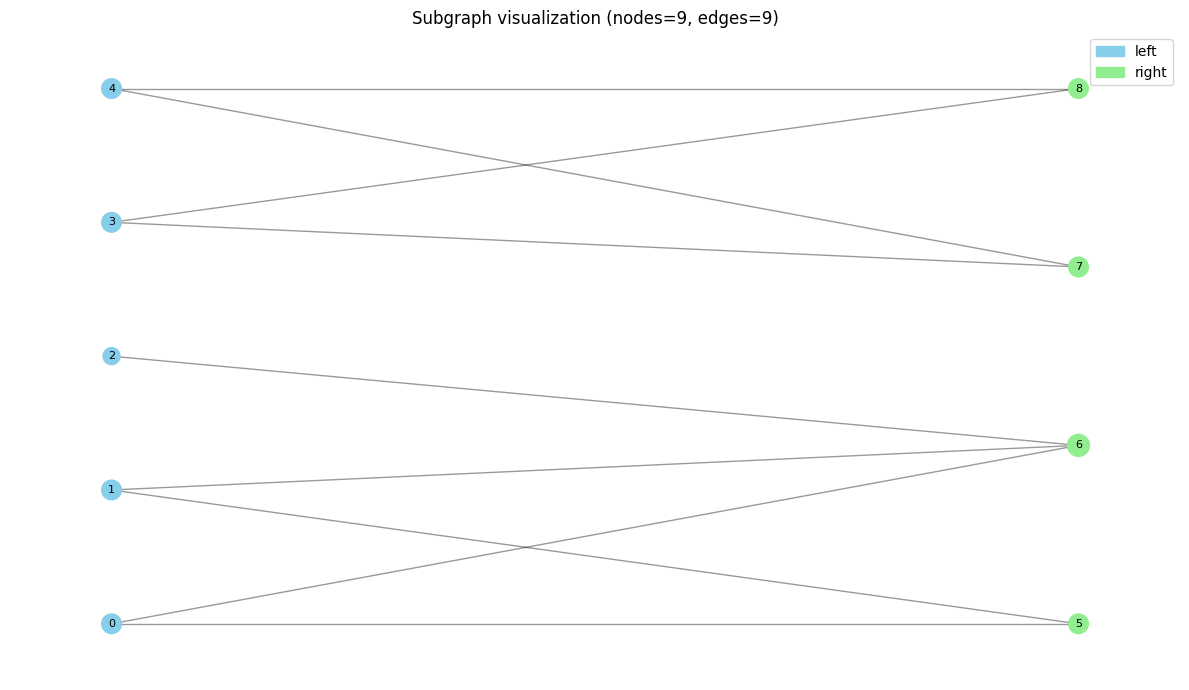

In [14]:

# improved visualization for very large bipartite graphs
import matplotlib.pyplot as plt
import random
from networkx.algorithms import bipartite

# left_n, right_n, p = 10, 8, 0.1  # tweak sizes/probability as needed
# B = bipartite.random_graph(left_n, right_n, p, seed=43)
# edges = pd.DataFrame([(u, v) for u, v in B.edges()], columns=['left', 'right'])
edges = pd.DataFrame([["0","5"],["0","6"],
                     ["1","5"],["1","6"],
                     ["2","6"],["3","7"],
                     ["3","8"],["4","7"],
                     ["4","8"]])
edges.to_csv("/home/edu/Area_de_Trabalho/Projs/links/code/exemplo.csv",index=False,header=False)
# assume first two columns are the edge endpoints
if edges.shape[1] < 2:
    raise ValueError("CSV must have at least two columns for an edge list")

u_col, v_col = edges.columns[0], edges.columns[1]

# build full graph
G = nx.Graph()
G.add_edges_from(edges[[u_col, v_col]].itertuples(index=False, name=None))

# define the two node sets
left_nodes = set(edges[u_col].unique())
right_nodes = set(edges[v_col].unique())

for n in left_nodes:
    G.nodes[n]['bipartite'] = 0
for n in right_nodes:
    G.nodes[n]['bipartite'] = 1

# Parameters you can tweak:
TOP_K = 20           # keep top-K nodes by degree on each side
RANDOM_SAMPLE = 0.0  # fraction [0..1] of edges to randomly sample if >0 (alternative to TOP_K)

# If user wants random sampling instead of top-K, set RANDOM_SAMPLE > 0.
if RANDOM_SAMPLE > 0 and 0 < RANDOM_SAMPLE < 1:
    all_edges = list(G.edges())
    sampled = random.sample(all_edges, int(len(all_edges) * RANDOM_SAMPLE))
    subG = G.edge_subgraph(sampled).copy()
else:
    # pick top-K nodes by degree on each side
    deg = dict(G.degree())

    left_deg_sorted = sorted([n for n in left_nodes if n in deg], key=lambda x: deg[x], reverse=True)
    right_deg_sorted = sorted([n for n in right_nodes if n in deg], key=lambda x: deg[x], reverse=True)

    top_left = set(left_deg_sorted[:TOP_K])
    top_right = set(right_deg_sorted[:TOP_K])

    # keep edges that connect the chosen left and right sets
    filtered_edges = [(u, v) for u, v in G.edges() if (u in top_left and v in top_right) or (v in top_left and u in top_right)]
    if not filtered_edges:
        raise RuntimeError("No edges between selected top nodes. Increase TOP_K or use RANDOM_SAMPLE.")

    subG = G.edge_subgraph(filtered_edges).copy()

# prepare nodes for layout
left_sub = [n for n in subG.nodes if subG.nodes[n].get('bipartite') == 0]
right_sub = [n for n in subG.nodes if subG.nodes[n].get('bipartite') == 1]

# choose layout: bipartite_layout if node partition is preserved, otherwise fallback to spring
if left_sub and right_sub:
    pos = nx.bipartite_layout(subG, left_sub)
else:
    pos = nx.spring_layout(subG, seed=42)

# draw
plt.figure(figsize=(12, 7))
sizes = [100 + 50 * subG.degree(n) for n in subG.nodes()]  # scale by degree for emphasis
colors = ['skyblue' if subG.nodes[n].get('bipartite') == 0 else 'lightgreen' for n in subG.nodes()]

nx.draw_networkx_nodes(subG, pos, node_size=sizes, node_color=colors)
nx.draw_networkx_edges(subG, pos, alpha=0.4, width=1)

# draw labels (small font to avoid overlap)
nx.draw_networkx_labels(subG, pos, font_size=8, font_color='black')

plt.axis('off')
# custom legend
import matplotlib.patches as mpatches
left_patch = mpatches.Patch(color='skyblue', label='left')
right_patch = mpatches.Patch(color='lightgreen', label='right')
plt.legend(handles=[left_patch, right_patch], loc='upper right')
plt.title(f"Subgraph visualization (nodes={subG.number_of_nodes()}, edges={subG.number_of_edges()})")
plt.tight_layout()
plt.show()